In [6]:
!pip install -q --no-deps gTTS==2.5.4

In [7]:
from gtts import gTTS

print("gTTS is working!")

gTTS is working!


In [10]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

print("Step 1: Generating text...")

# Load FLAN-T5
model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16
).to("cuda")

# Prompt
topic = "The benefits of renewable energy"

text_prompt = f"Write a short, engaging paragraph about: {topic}"

# Convert text into tokens
inputs = tokenizer(
    text_prompt,
    return_tensors="pt"
).to("cuda")

# Generate text
outputs = model.generate(
    **inputs,
    max_new_tokens=100,
    do_sample=True,
    temperature=0.8
)

# Convert tokens back to text
generated_text = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print("\nGenerated Text:")
print(generated_text)

Step 1: Generating text...


tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]


Generated Text:
Renewable energy provides energy, and the best of both worlds.



Step 2: Loading Stable Diffusion...


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Generating image...


  0%|          | 0/20 [00:00<?, ?it/s]

Image saved as content_image.png


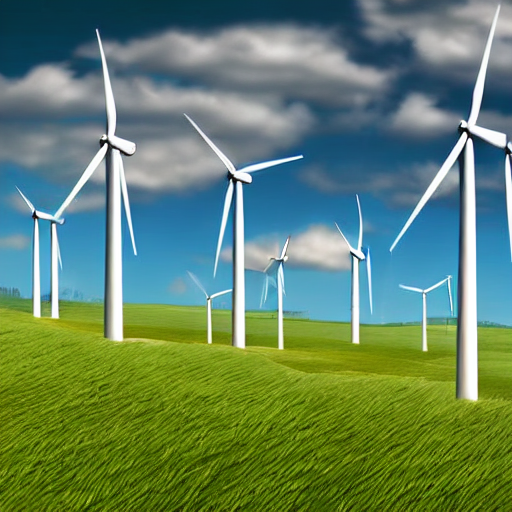

In [11]:
from diffusers import StableDiffusionPipeline

print("\nStep 2: Loading Stable Diffusion...")

sd_pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)

sd_pipe = sd_pipe.to("cuda")

# Reduce GPU memory usage
sd_pipe.enable_attention_slicing()

image_prompt = (
    f"An attractive digital illustration representing {topic}, "
    "solar panels, wind turbines, green landscape, clean environment, "
    "bright sky, professional digital art"
)

print("Generating image...")

image = sd_pipe(
    image_prompt,
    num_inference_steps=20
).images[0]

image.save("content_image.png")

print("Image saved as content_image.png")

display(image)